In [1]:
import sys, os, time
sys.path.append(os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from decision_tree import DecisionTree
from random_forest import RandomForest
from metric_tracker import MetricTracker
from model_visualizer import ModelVisualizer

from itertools import product
from typing import Dict, List, Any

from sklearn.model_selection import (
    KFold,
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.metrics import make_scorer, f1_score
from sklearn.inspection import permutation_importance

In [2]:
tracker = MetricTracker()
viz = ModelVisualizer()
dataset_path = "../dataset/dataset_preprocessed.csv"
dataset = pd.read_csv(dataset_path)
y = dataset['Diabetes_binary']
X = dataset.drop(columns=['Diabetes_binary'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
dataset.head()

Training samples: 56936, Test samples: 14234


,ordinal_scaler__GenHlth,ordinal_scaler__MentHlth,ordinal_scaler__PhysHlth,ordinal_scaler__AgeGroup,ordinal_scaler__Education,ordinal_scaler__Income,bmi_scaler__BMI,pass_nominal__KidneyDisease,pass_nominal__HighBP,pass_nominal__HighChol,...,pass_nominal__Smoker,pass_nominal__Stroke,pass_nominal__HeartDiseaseorAttack,pass_nominal__HvyAlcoholConsump,pass_nominal__AnyHealthcare,pass_nominal__NoDocbcCost,pass_nominal__DiffWalk,pass_nominal__Sex,remainder__PhysActivity,Diabetes_binary
0,-0.5,0.0,0.000000,-0.75,-0.5,0.75,0.293794,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.000000,-0.50,0.0,0.50,0.937437,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.166667,-1.50,-1.5,-1.25,0.794795,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,3.0,0.000000,-2.00,-0.5,0.25,0.617117,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-0.5,0.0,0.000000,0.50,-0.5,-1.25,0.500000,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


# K-Fold Cross Validation

### Custom CV

In [34]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "rf_probs": RandomForest(store_probs=True),
    "rf_labels": RandomForest(store_probs=False),
    "dt_probs": DecisionTree(store_probs=True),
    "dt_labels": DecisionTree(store_probs=False)
}
metrics = {}

def cross_validate(model_name, model, X, y, kf):
    tracker.clear_cv_history()
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)

        row = tracker.compute_cv_metrics(model_name, model, X_val, y_val)
        row["fold"] = fold_idx
        tracker.add_cv_row(row)
    return tracker.cv_to_df()

for model_name, model in models.items():
    print(f"Cross validating {model_name}...")
    start_time = time.time()

    metrics[f"cv_{model_name}"] = cross_validate(model_name, model, X_train, y_train, kf)
    
    runtime = time.time() - start_time
    print(f"Cross validation finished in {runtime}\n")

metrics['cv_rf_probs']

Cross validating rf_probs...
Cross validation finished in 65.64138126373291

Cross validating rf_labels...
Cross validation finished in 67.11167621612549

Cross validating dt_probs...
Cross validation finished in 1.0350141525268555

Cross validating dt_labels...
Cross validation finished in 0.9368088245391846



,model,accuracy,precision,recall,f1,roc,logloss,fold
4,rf_probs,0.737596,0.740587,0.737596,0.735008,0.810309,0.542482,4
1,rf_probs,0.737069,0.744018,0.737069,0.732791,0.812753,0.541055,1
3,rf_probs,0.734171,0.738363,0.734171,0.730691,0.811806,0.541100,3
2,rf_probs,0.731273,0.733945,0.731273,0.728145,0.800826,0.548207,2
0,rf_probs,0.730067,0.731594,0.730067,0.727779,0.804818,0.547548,0


In [35]:
metrics['cv_rf_labels']

,model,accuracy,precision,recall,f1,roc,logloss,fold
1,rf_labels,0.735049,0.738678,0.735049,0.732122,0.813315,0.541730,1
4,rf_labels,0.733468,0.734873,0.733468,0.731622,0.810927,0.541801,4
3,rf_labels,0.734610,0.739130,0.734610,0.730992,0.810202,0.541384,3
0,rf_labels,0.727257,0.731396,0.727257,0.723437,0.804578,0.546764,0
2,rf_labels,0.725389,0.729389,0.725389,0.721327,0.801000,0.547665,2


In [36]:
metrics['cv_dt_probs']

,model,accuracy,precision,recall,f1,roc,logloss,fold
1,dt_probs,0.688153,0.687825,0.688153,0.687086,0.744988,0.582784,1
4,dt_probs,0.682972,0.682512,0.682972,0.682108,0.738728,0.588216,4
2,dt_probs,0.682796,0.682106,0.682796,0.681567,0.736455,0.589721,2
3,dt_probs,0.682884,0.682421,0.682884,0.681562,0.738559,0.586541,3
0,dt_probs,0.677907,0.677254,0.677907,0.676929,0.733807,0.591636,0


In [37]:
metrics['cv_dt_labels']

,model,accuracy,precision,recall,f1,roc,logloss,fold
1,dt_labels,0.688153,0.687825,0.688153,0.687086,0.744988,0.582784,1
4,dt_labels,0.682972,0.682512,0.682972,0.682108,0.738728,0.588216,4
2,dt_labels,0.682796,0.682106,0.682796,0.681567,0.736455,0.589721,2
3,dt_labels,0.682884,0.682421,0.682884,0.681562,0.738559,0.586541,3
0,dt_labels,0.677907,0.677254,0.677907,0.676929,0.733807,0.591636,0


### Scikit-learn CV

In [4]:
rf_single = RandomForest(n_estimators=100, max_depth=10, store_probs=True)

scores = cross_val_score(
    rf_single,
    X_train, y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print(f"5-Fold CV F1 Scores: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

5-Fold CV F1 Scores: [0.76868002 0.77554815 0.76506537 0.77351218 0.7697853 ]
Mean F1: 0.7705 (+/- 0.0037)


# Hyperparameter Tuning

### Random Forest - Randomized Search

In [6]:
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt'],
    'store_probs': [True, False]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForest(),
    param_distributions=rf_param_grid,
    n_iter=20,                     # Try 20 random combinations
    cv=5,
    scoring='f1',
    n_jobs=-1,                     # PARALLEL
    verbose=2,
    random_state=42,
    return_train_score=True,
    refit=True
)

print("\nStarting Random Search...")
start_time = time.time()
rf_random.fit(X_train, y_train)
elapsed = time.time() - start_time

results_random = pd.DataFrame(rf_random.cv_results_)
results_random.to_csv("rsc/rf_randomizedsearch_results.csv", index=False)

print(f"\nRandom Search completed in {elapsed:.2f} seconds")
print(f"Best F1 Score: {rf_random.best_score_:.4f}")
print(f"Best Parameters: {rf_random.best_params_}")


Starting Random Search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50, store_probs=True; total time=  27.5s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50, store_probs=True; total time=  27.3s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50, store_probs=True; total time=  27.5s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50, store_probs=True; total time=  27.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50, store_probs=True; total time=  28.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=50, store_probs=True; total time= 1.6min
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=50, store_probs=True; total time= 1.6min
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=50, store_probs=True;

### Random Forest - Grid Search

In [8]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt'],
    'store_probs': [True, False]
}

rf_multi = GridSearchCV(
    estimator=RandomForest(),
    param_grid=rf_param_grid,
    cv=3,
    scoring=scoring,
    refit='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("\nStarting Grid Search...")
rf_multi.fit(X_train, y_train)

print(f"\nBest F1 Score: {rf_multi.best_score_:.4f}")
print(f"Best Parameters: {rf_multi.best_params_}")

# View all metrics for best model
results_multi = pd.DataFrame(rf_multi.cv_results_)
results_multi.to_csv("rsc/rf_gridsearch_results.csv", index=False)
best_idx = rf_multi.best_index_

print("\nAll metrics for best configuration:")
for metric in scoring.keys():
    mean_score = results_multi.loc[best_idx, f'mean_test_{metric}']
    std_score = results_multi.loc[best_idx, f'std_test_{metric}']
    print(f"  {metric}: {mean_score:.4f} (+/- {std_score:.4f})")


Starting Grid Search...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best F1 Score: 0.7751
Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50, 'store_probs': False}

All metrics for best configuration:
  accuracy: 0.7429 (+/- 0.0036)
  precision: 0.7246 (+/- 0.0063)
  recall: 0.8334 (+/- 0.0052)
  f1: 0.7751 (+/- 0.0014)
  roc_auc: nan (+/- nan)


### Decision Tree - Randomized Search

In [33]:
dt_param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'store_probs': [True, False]
}

dt_custom = RandomizedSearchCV(
    estimator=DecisionTree(),
    param_distributions=dt_param_grid,
    cv=3,
    scoring='f1',      # Use custom scorer
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("\nStarting Randomized Search...")
dt_custom.fit(X_train, y_train)

results_dt_random = pd.DataFrame(dt_custom.cv_results_)
results_dt_random.to_csv("rsc/dt_randomizedsearch_results.csv", index=False)

print(f"\nBest Macro F1 Score: {dt_custom.best_score_:.4f}")
print(f"Best Parameters: {dt_custom.best_params_}")


Starting Randomized Search...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Macro F1 Score: 0.7625
Best Parameters: {'store_probs': True, 'min_samples_split': 5, 'max_depth': 5}


### Decision Tree - Grid Search

In [39]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

dt_param_grid = {
    
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20, 50],
    'store_probs': [True, False]
}

dt_grid = GridSearchCV(
    estimator=DecisionTree(),
    param_grid=dt_param_grid,
    cv=3,
    scoring=scoring,
    refit='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("\nStarting Grid Search...")
dt_grid.fit(X_train, y_train)

print(f"\nBest F1 Score: {dt_grid.best_score_:.4f}")
print(f"Best Parameters: {dt_grid.best_params_}")

# View all metrics for best model
results_multi = pd.DataFrame(dt_grid.cv_results_)
results_multi.to_csv("rsc/dt_gridsearch_results.csv", index=False)
best_idx = dt_grid.best_index_

print("\nAll metrics for best configuration:")
for metric in scoring.keys():
    mean_score = results_multi.loc[best_idx, f'mean_test_{metric}']
    std_score = results_multi.loc[best_idx, f'std_test_{metric}']
    print(f"  {metric}: {mean_score:.4f} (+/- {std_score:.4f})")


Starting Grid Search...
Fitting 3 folds for each of 60 candidates, totalling 180 fits

Best F1 Score: 0.7625
Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'store_probs': True}

All metrics for best configuration:
  accuracy: 0.7293 (+/- 0.0014)
  precision: 0.7146 (+/- 0.0021)
  recall: 0.8173 (+/- 0.0080)
  f1: 0.7625 (+/- 0.0024)
  roc_auc: nan (+/- nan)


# Metrics

In [ ]:
rf_random = RandomForest(n_estimators=100, max_depth=15, min_samples_split=2, store_probs=True)
rf_grid = RandomForest(n_estimators=50, max_depth=15, min_samples_split=5, store_probs=False)
dt_random = DecisionTree(max_depth=5, min_samples_split=2, store_probs=True)  # Grid Search has the same values.

rf_random.fit(X_train, y_train)
rf_grid.fit(X_train, y_train)
dt_random.fit(X_train, y_train)

### Consistency

In [ ]:
rf_list = []
for i in range(10):
    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=True
    )
    rf = RandomForest(n_estimators=50, max_depth=15, min_samples_split=5, store_probs=False)
    rf.fit(X_train_new, y_train_new)
    row = tracker.compute_test_metrics(f'Random Forest {i+1}', rf, X_test_new, y_test_new)
    rf_list.append(tracker.test_to_df(refit="f1"))
pd.concat(rf_list, ignore_index=True)

,model,accuracy,precision,recall,f1,roc,logloss
0,Random Forest 1,0.740481,0.743639,0.740481,0.737853,0.818198,0.516872
1,Random Forest 2,0.741675,0.744205,0.741675,0.739373,0.817739,0.516787
2,Random Forest 3,0.741745,0.745293,0.741745,0.738973,0.815928,0.518799
3,Random Forest 4,0.743993,0.747214,0.743993,0.741425,0.816023,0.518479
4,Random Forest 5,0.741043,0.744692,0.741043,0.738206,0.817089,0.517368
5,Random Forest 6,0.741394,0.745476,0.741394,0.738376,0.816509,0.518054
6,Random Forest 7,0.743080,0.746417,0.743080,0.740436,0.815306,0.519510
7,Random Forest 8,0.741956,0.744822,0.741956,0.739501,0.815741,0.518869
8,Random Forest 9,0.741183,0.744765,0.741183,0.738380,0.816463,0.518309
9,Random Forest 10,0.740410,0.743592,0.740410,0.737771,0.816844,0.517895


In [41]:
dt_list = []
for i in range(10):
    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=True
    )
    dt = DecisionTree(max_depth=5, min_samples_split=2, store_probs=True)
    dt.fit(X_train_new, y_train_new)
    row = tracker.compute_test_metrics(f'Decision Tree {i+1}', dt, X_test_new, y_test_new)
    dt_list.append(tracker.test_to_df(refit="f1"))
pd.concat(dt_list, ignore_index=True)

,model,accuracy,precision,recall,f1,roc,logloss
0,Decision Tree 1,0.729099,0.732209,0.729099,0.726241,0.791653,0.545123
1,Decision Tree 2,0.734509,0.738535,0.734509,0.731241,0.795872,0.538289
2,Decision Tree 3,0.730575,0.732333,0.730575,0.728410,0.793994,0.540858
3,Decision Tree 4,0.724041,0.725141,0.724041,0.721869,0.785054,0.550894
4,Decision Tree 5,0.732682,0.734711,0.732682,0.729849,0.789399,0.545047
5,Decision Tree 6,0.725306,0.727662,0.725306,0.722586,0.784681,0.550652
6,Decision Tree 7,0.733385,0.736152,0.733385,0.730444,0.791812,0.543667
7,Decision Tree 8,0.733666,0.737521,0.733666,0.730427,0.792510,0.543554
8,Decision Tree 9,0.729872,0.732462,0.729872,0.727077,0.792009,0.543833
9,Decision Tree 10,0.725095,0.727435,0.725095,0.722105,0.786440,0.548956


### Permutation Feature Importance

In [6]:
def plot_perm_importance(result, feature_names, title, top_k=20):
    importances = result.importances_mean
    std = result.importances_std

    indices = np.argsort(importances)[::-1][:top_k]

    plt.figure(figsize=(8, 5))
    plt.barh(
        range(len(indices)),
        importances[indices][::-1],
        xerr=std[indices][::-1],
        align="center"
    )
    plt.yticks(range(len(indices)), feature_names[indices][::-1])
    plt.xlabel("Mean decrease in score")
    plt.title(title)
    plt.tight_layout()
    plt.show()

feature_names = X_test.columns.to_numpy()
feature_names

array(['ordinal_scaler__GenHlth', 'ordinal_scaler__MentHlth',
       'ordinal_scaler__PhysHlth', 'ordinal_scaler__AgeGroup',
       'ordinal_scaler__Education', 'ordinal_scaler__Income',
       'bmi_scaler__BMI', 'pass_nominal__KidneyDisease',
       'pass_nominal__HighBP', 'pass_nominal__HighChol',
       'pass_nominal__CholCheck', 'pass_nominal__Asthma',
       'pass_nominal__COPD', 'pass_nominal__Smoker',
       'pass_nominal__Stroke', 'pass_nominal__HeartDiseaseorAttack',
       'pass_nominal__HvyAlcoholConsump', 'pass_nominal__AnyHealthcare',
       'pass_nominal__NoDocbcCost', 'pass_nominal__DiffWalk',
       'pass_nominal__Sex', 'remainder__PhysActivity'], dtype=object)

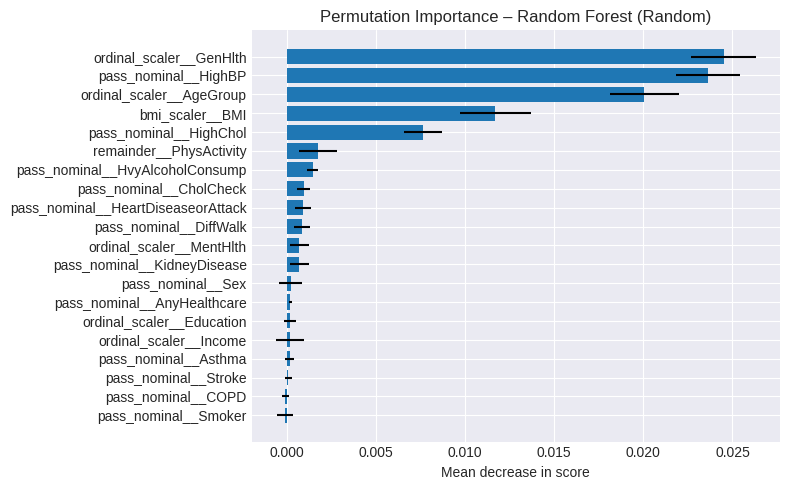

In [9]:
result_rf_random = permutation_importance(rf_random, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring="f1")
plot_perm_importance(result_rf_random, feature_names=feature_names, title="Permutation Importance – Random Forest (Random)")

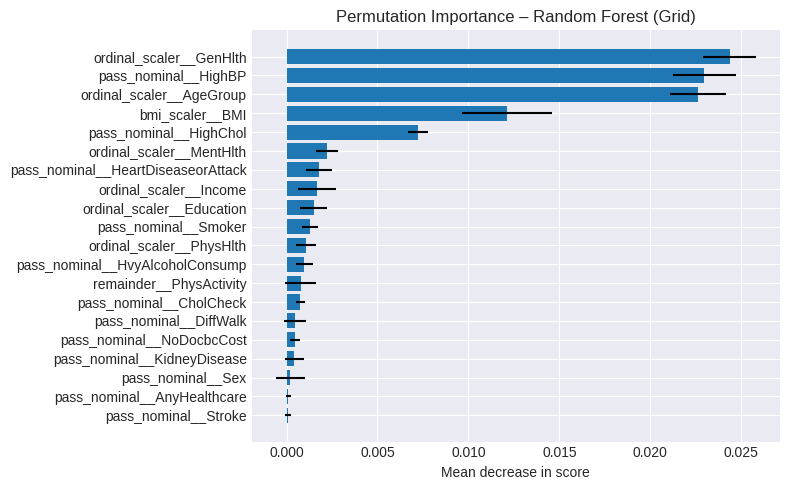

In [10]:
result_rf_grid = permutation_importance(rf_grid, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring="f1")
plot_perm_importance(result_rf_grid, feature_names=feature_names, title="Permutation Importance – Random Forest (Grid)")

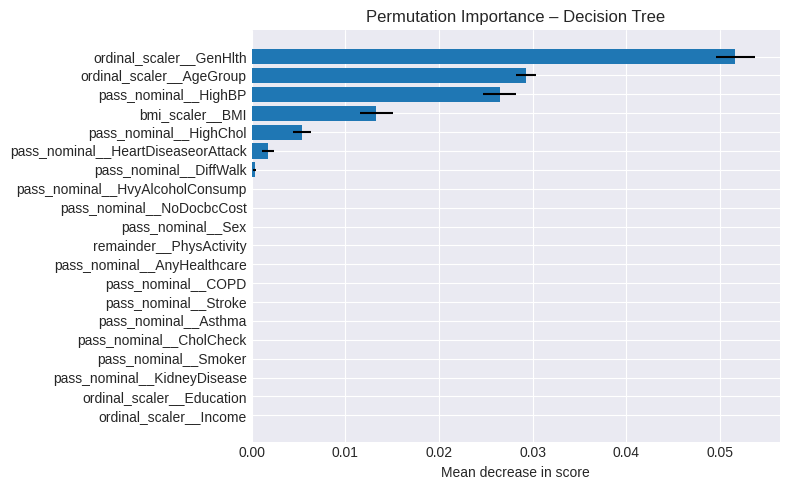

In [8]:
result_dt_random = permutation_importance(dt_random, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring="f1")
plot_perm_importance(result_dt_random, feature_names=feature_names, title="Permutation Importance – Decision Tree")

### Learning Curve

Computing learning curve...


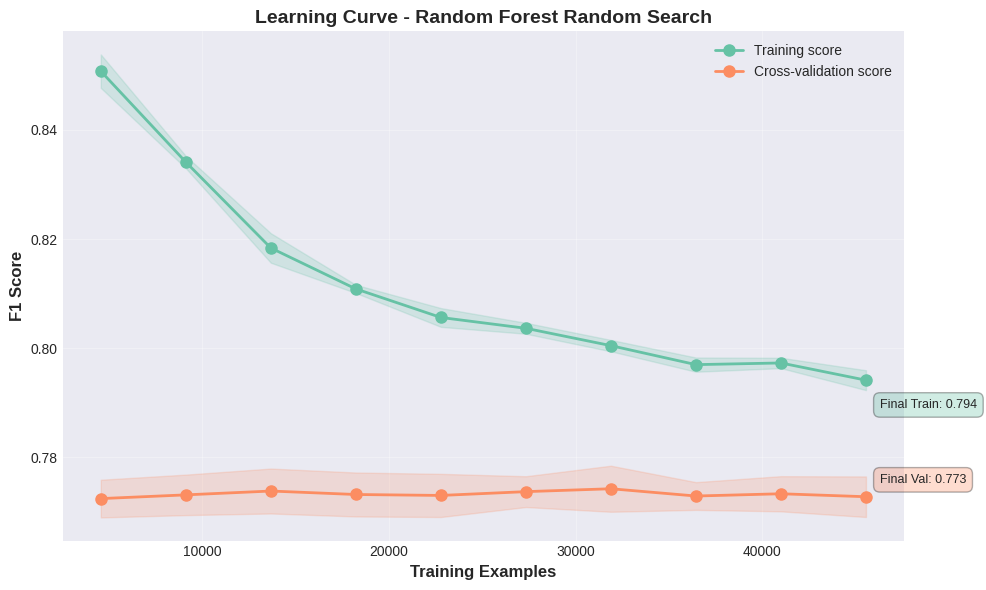


Learning Curve Summary:
Final Training Score: 0.7941 (±0.0018)
Final Validation Score: 0.7728 (±0.0037)
Gap (Overfitting): 0.0213


In [19]:
viz.plot_learning_curve(
    estimator=rf_random,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    title='Learning Curve - Random Forest Random Search'
)

Computing learning curve...


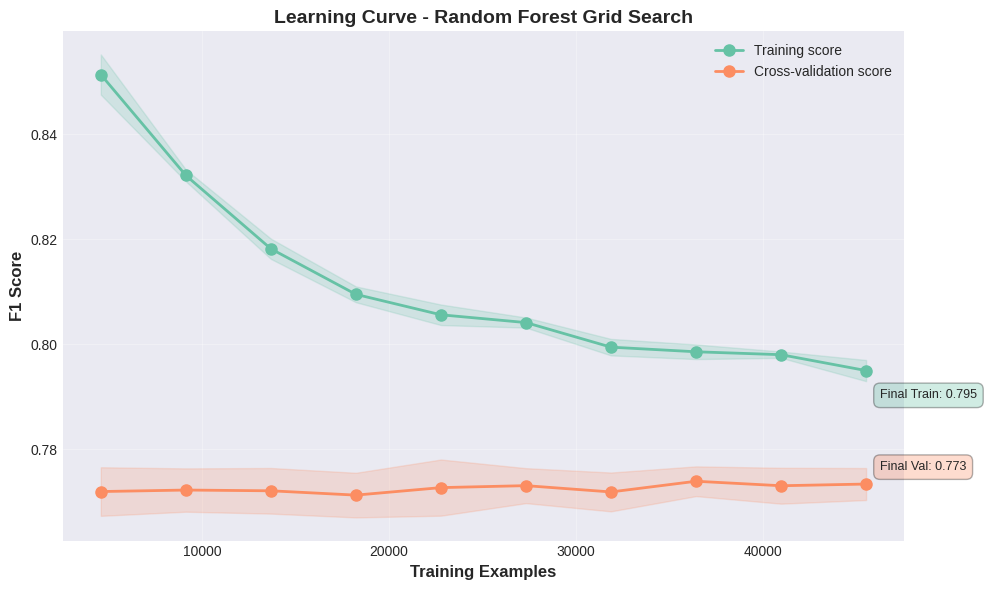


Learning Curve Summary:
Final Training Score: 0.7950 (±0.0020)
Final Validation Score: 0.7734 (±0.0030)
Gap (Overfitting): 0.0216


In [20]:
viz.plot_learning_curve(
    estimator=rf_grid,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    title='Learning Curve - Random Forest Grid Search'
)

Computing learning curve...


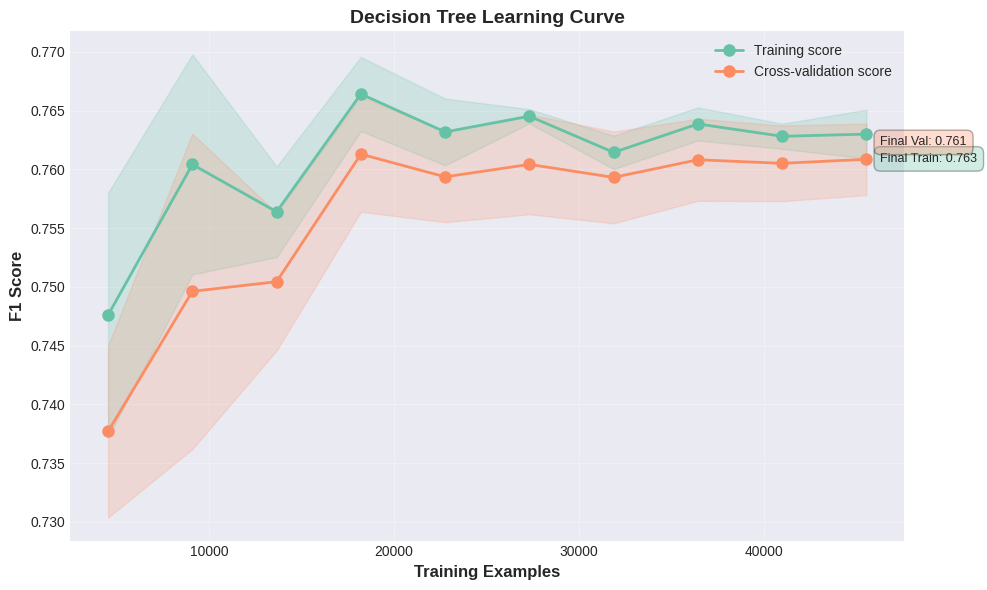


Learning Curve Summary:
Final Training Score: 0.7630 (±0.0021)
Final Validation Score: 0.7609 (±0.0030)
Gap (Overfitting): 0.0021


In [25]:
viz.plot_learning_curve(
    estimator=dt_random,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    title='Decision Tree Learning Curve'
)

### Overfitting/Underfitting

Computing overfitting analysis...


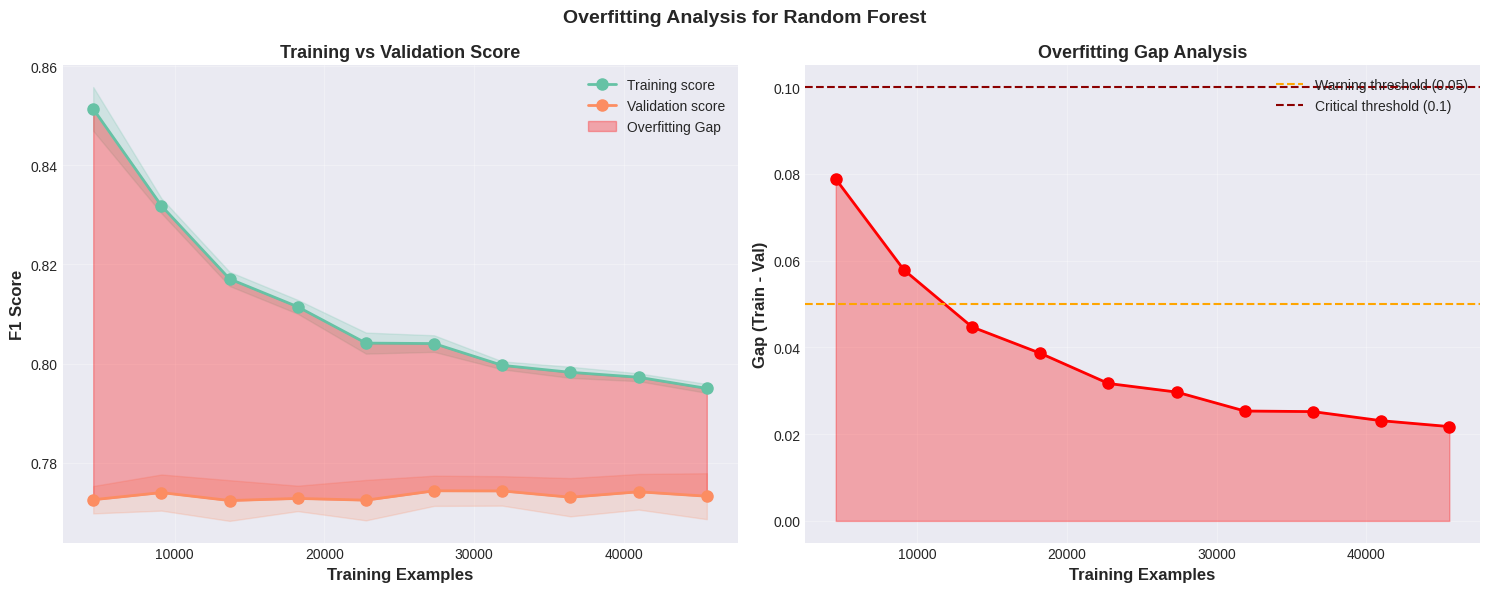


OVERFITTING ANALYSIS
Final Training Score:   0.7950 (±0.0009)
Final Validation Score: 0.7733 (±0.0046)
Overfitting Gap:        0.0217

Diagnosis:
✓ Good. Minor overfitting detected.



In [22]:
viz.plot_overfitting_analysis(
    estimator=rf_random,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    title='Overfitting Analysis for Random Forest'
)

Computing overfitting analysis...


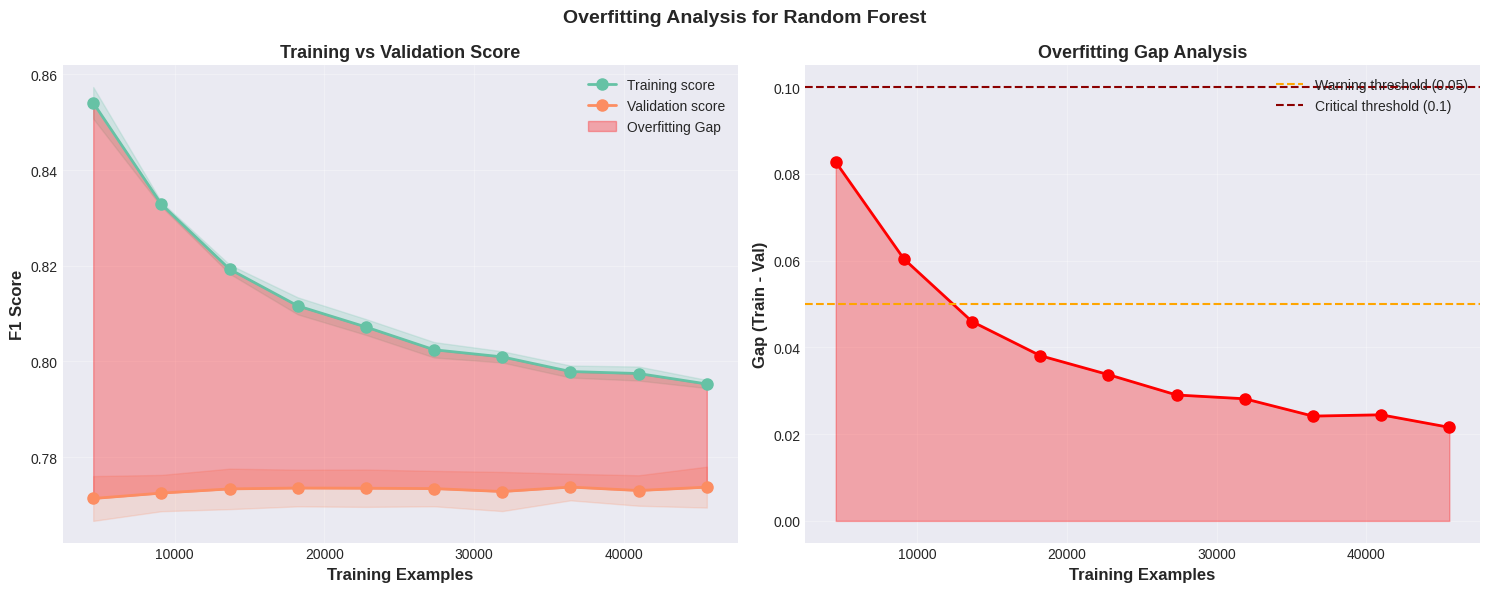


OVERFITTING ANALYSIS
Final Training Score:   0.7953 (±0.0008)
Final Validation Score: 0.7737 (±0.0043)
Overfitting Gap:        0.0216

Diagnosis:
✓ Good. Minor overfitting detected.



In [ ]:
viz.plot_overfitting_analysis(
    estimator=rf_grid,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    title='Overfitting Analysis for Random Forest'
)

Computing overfitting analysis...


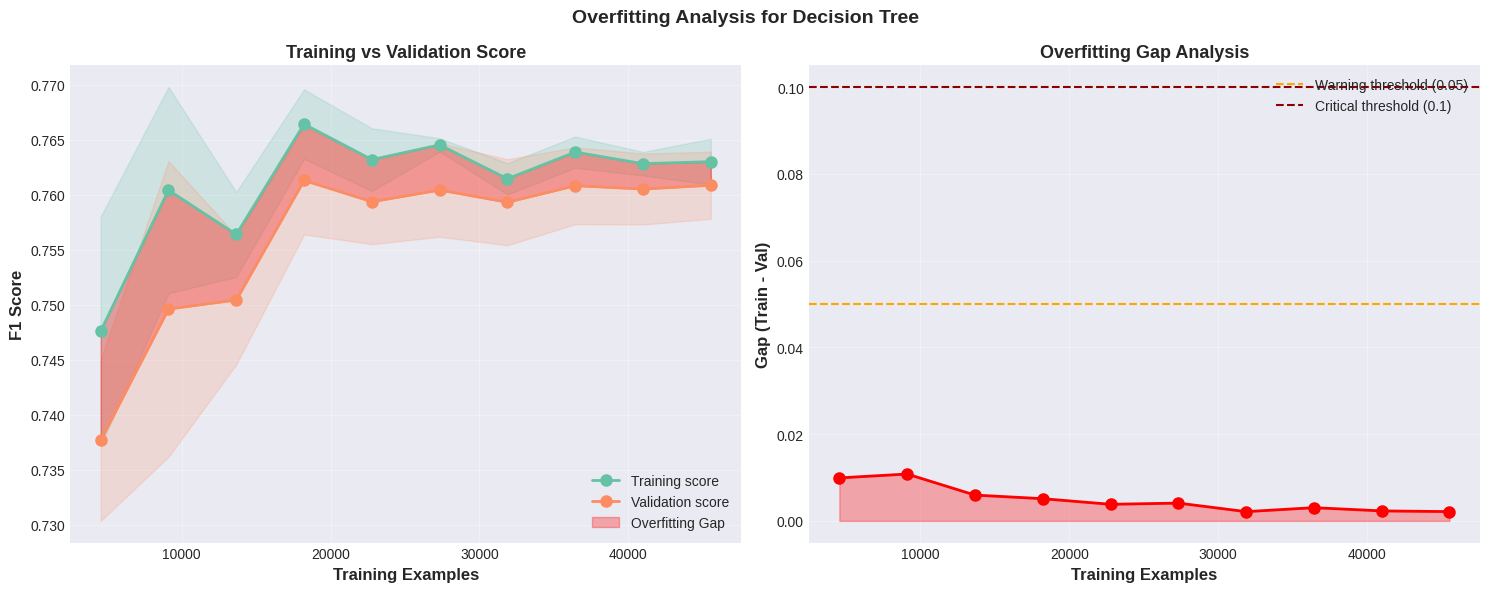


OVERFITTING ANALYSIS
Final Training Score:   0.7630 (±0.0021)
Final Validation Score: 0.7609 (±0.0030)
Overfitting Gap:        0.0021

Diagnosis:
✓ Excellent! Model is well-balanced.



In [7]:
viz.plot_overfitting_analysis(
    estimator=dt_random,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    title='Overfitting Analysis for Decision Tree'
)

### Validation Curve

Computing validation curve for max_depth...


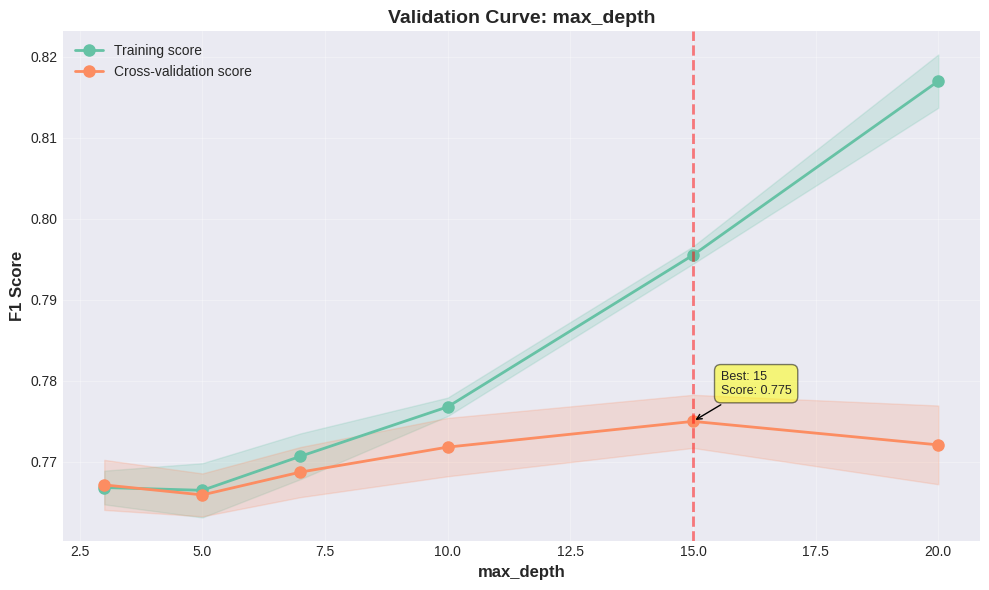


Validation Curve Summary:
Best max_depth: 15
Best Validation Score: 0.7750 (±0.0033)


In [ ]:
viz.plot_validation_curve(
    estimator=rf_random,
    X=X_train,
    y=y_train,
    param_name='max_depth',
    param_range=[3, 5, 7, 10, 15, 20],
    cv=5,
    scoring='f1',
    title='Validation Curve: max_depth'
)

Computing validation curve for n_estimators...


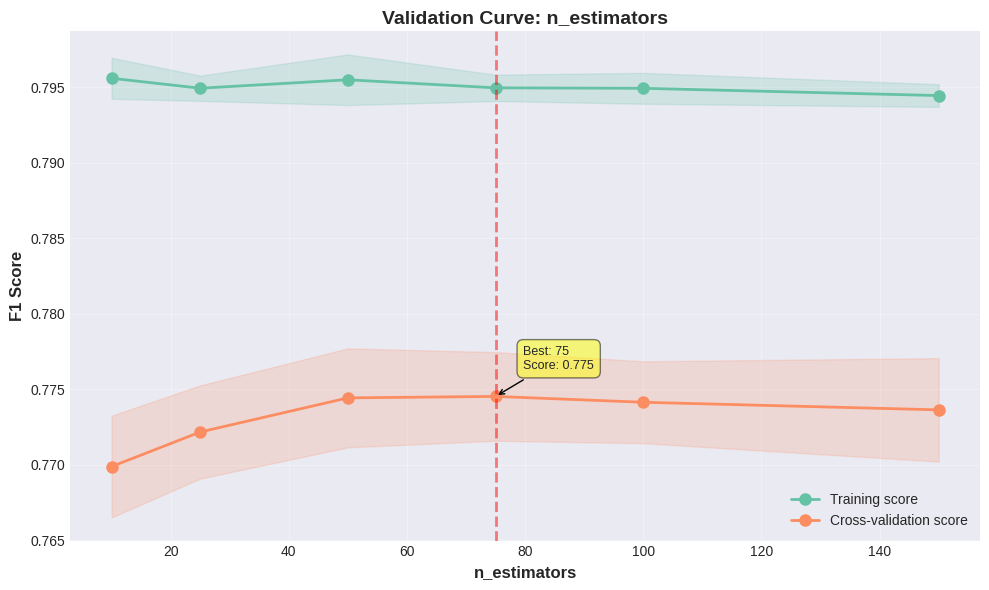


Validation Curve Summary:
Best n_estimators: 75
Best Validation Score: 0.7745 (±0.0029)


In [28]:
viz.plot_validation_curve(
    estimator=rf_random,
    X=X_train,
    y=y_train,
    param_name='n_estimators',
    param_range=[10, 25, 50, 75, 100, 150],
    cv=5,
    scoring='f1',
    title='Validation Curve: n_estimators'
)

### Confusion Matrix

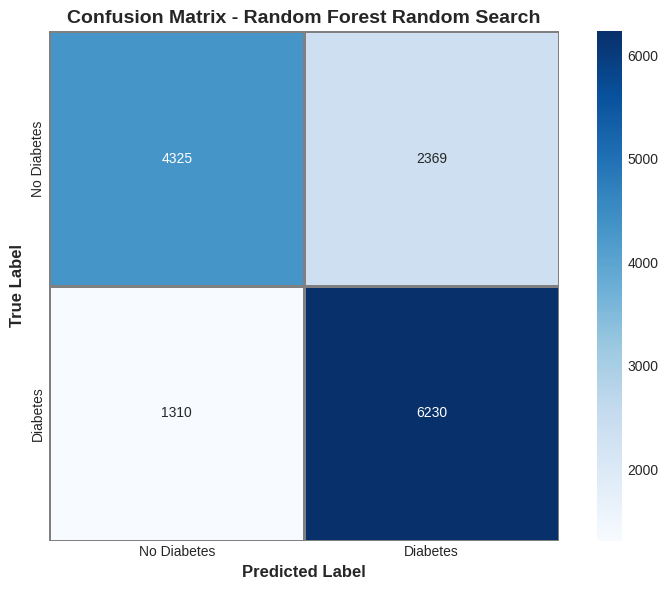


Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.77      0.65      0.70      6694
    Diabetes       0.72      0.83      0.77      7540

    accuracy                           0.74     14234
   macro avg       0.75      0.74      0.74     14234
weighted avg       0.74      0.74      0.74     14234



In [11]:
viz.plot_confusion_matrix(
    model=rf_random,
    X_test=X_test,
    y_test=y_test,
    labels=['No Diabetes', 'Diabetes'],
    normalize=None,
    title='Confusion Matrix - Random Forest Random Search'
)

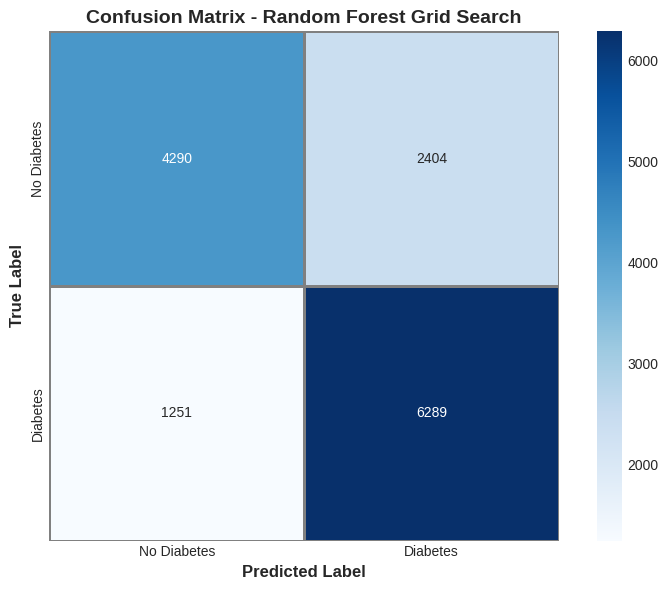


Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.77      0.64      0.70      6694
    Diabetes       0.72      0.83      0.77      7540

    accuracy                           0.74     14234
   macro avg       0.75      0.74      0.74     14234
weighted avg       0.75      0.74      0.74     14234



In [12]:
viz.plot_confusion_matrix(
    model=rf_grid,
    X_test=X_test,
    y_test=y_test,
    labels=['No Diabetes', 'Diabetes'],
    normalize=None,
    title='Confusion Matrix - Random Forest Grid Search'
)

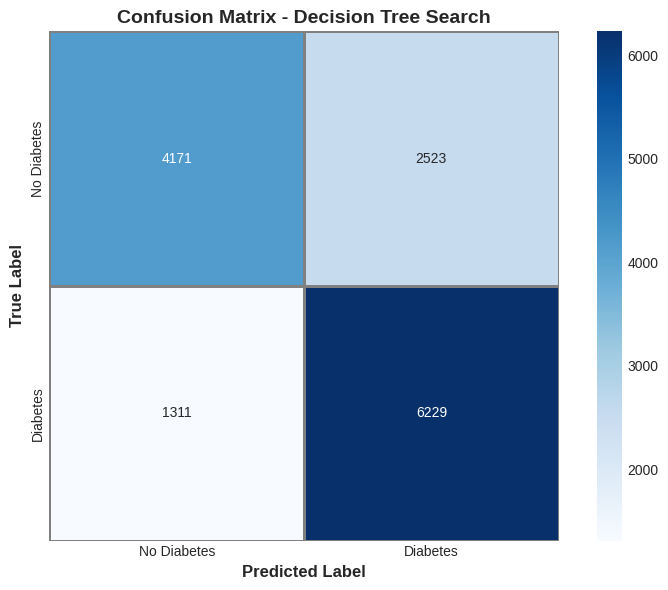


Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.76      0.62      0.69      6694
    Diabetes       0.71      0.83      0.76      7540

    accuracy                           0.73     14234
   macro avg       0.74      0.72      0.72     14234
weighted avg       0.73      0.73      0.73     14234



In [13]:
viz.plot_confusion_matrix(
    model=dt_random,
    X_test=X_test,
    y_test=y_test,
    labels=['No Diabetes', 'Diabetes'],
    normalize=None,
    title='Confusion Matrix - Decision Tree Search'
)

### ROC Curve

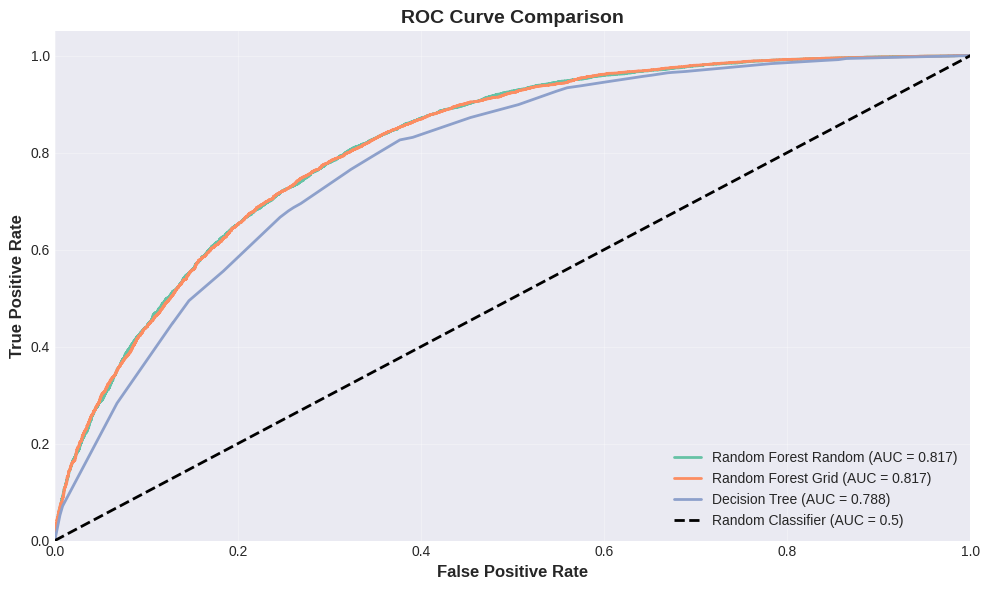

In [4]:
models_dict = {
    'Random Forest Random': rf_random,
    'Random Forest Grid': rf_grid,
    'Decision Tree': dt_random
}

viz.plot_roc_curve(
    models=models_dict,
    X_test=X_test,
    y_test=y_test,
    title='ROC Curve Comparison'
)

### Precision-Recall Curve

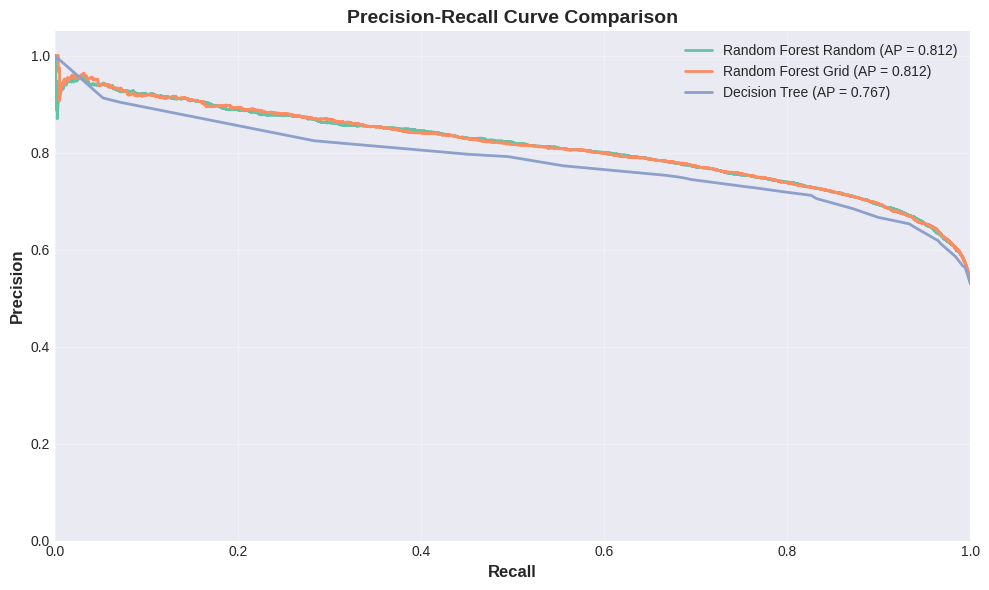

In [5]:
viz.plot_precision_recall_curve(
    models=models_dict,
    X_test=X_test,
    y_test=y_test,
    title='Precision-Recall Curve Comparison'
)

### Hyperparameter Heatmap

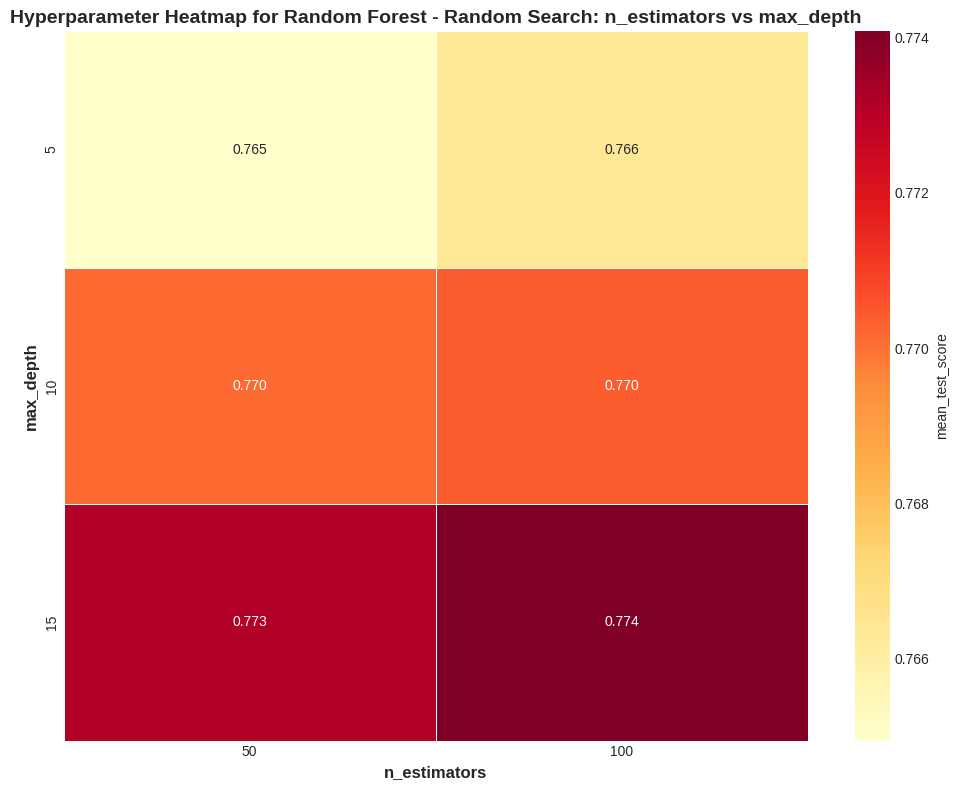

In [19]:
results_df = pd.read_csv('rsc/rf_randomizedsearch_results.csv')
viz.plot_hyperparameter_heatmap(
    results_df=results_df,
    param1='n_estimators',
    param2='max_depth',
    score_col='mean_test_score',
    title='Hyperparameter Heatmap for Random Forest - Random Search: n_estimators vs max_depth'
)

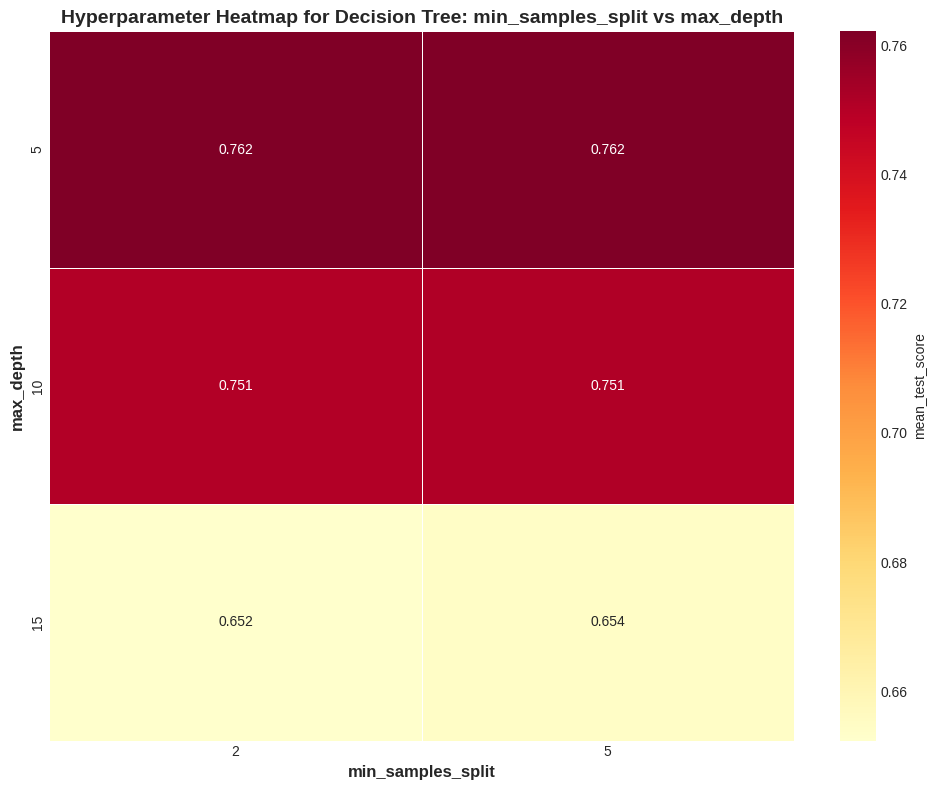

In [16]:
results_df = pd.read_csv('rsc/dt_randomizedsearch_results.csv')
viz.plot_hyperparameter_heatmap(
    results_df=results_df,
    param1='min_samples_split',
    param2='max_depth',
    score_col='mean_test_score',
    title='Hyperparameter Heatmap for Decision Tree: min_samples_split vs max_depth'
)

### Random Forest/Decision Tree Model Comparison

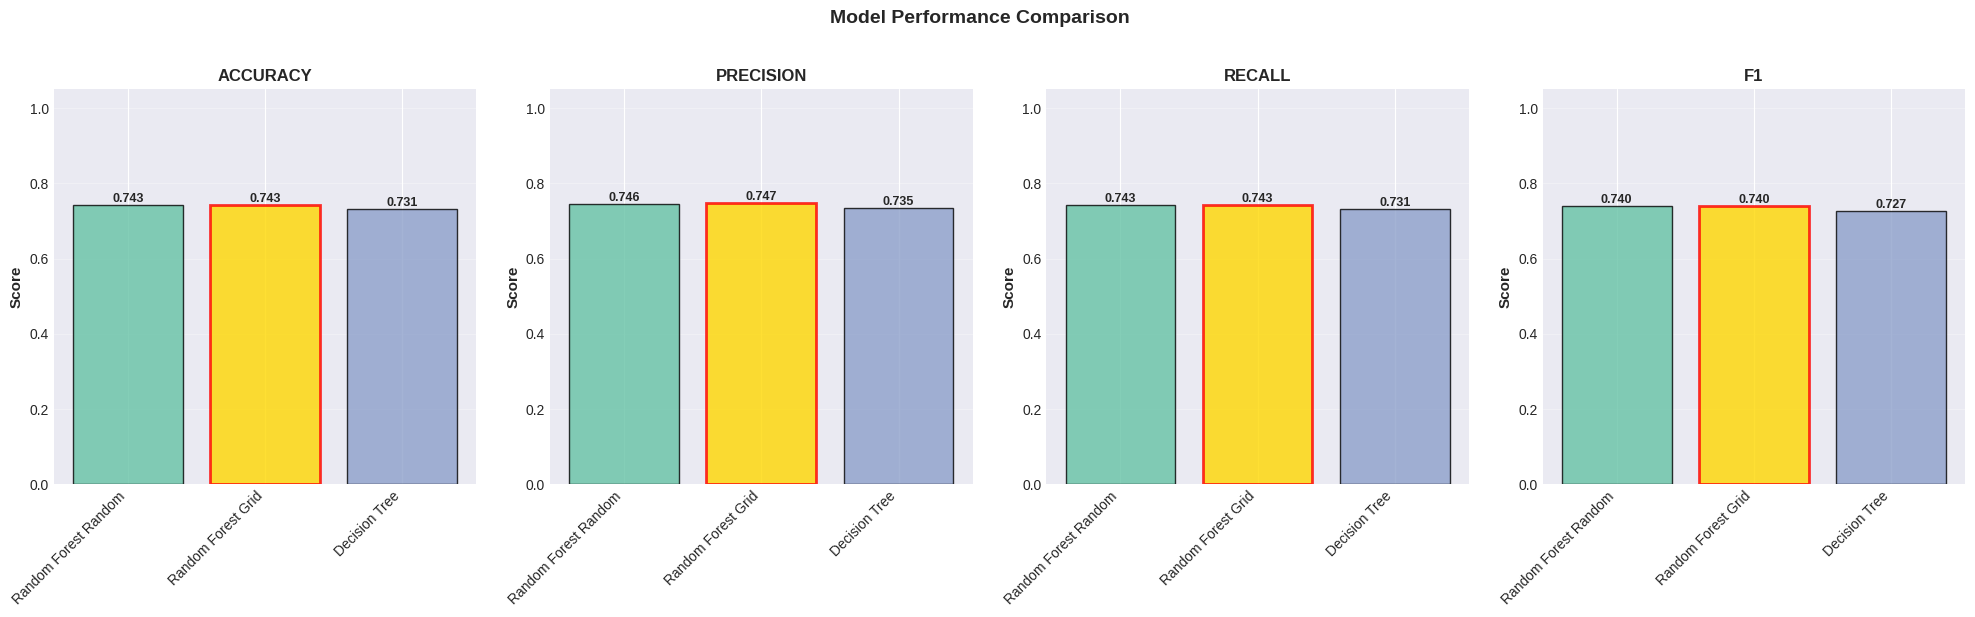

In [12]:
tracker = MetricTracker()

results = []
for name, model in models_dict.items():
    metrics = tracker.compute_test_metrics(name, model, X_test, y_test)
    results.append(metrics)

comparison_df = pd.DataFrame(results)

viz.plot_model_comparison(
    results_df=comparison_df,
    metrics=['accuracy', 'precision', 'recall', 'f1'],
    title='Model Performance Comparison'
)

### Calibration Curve

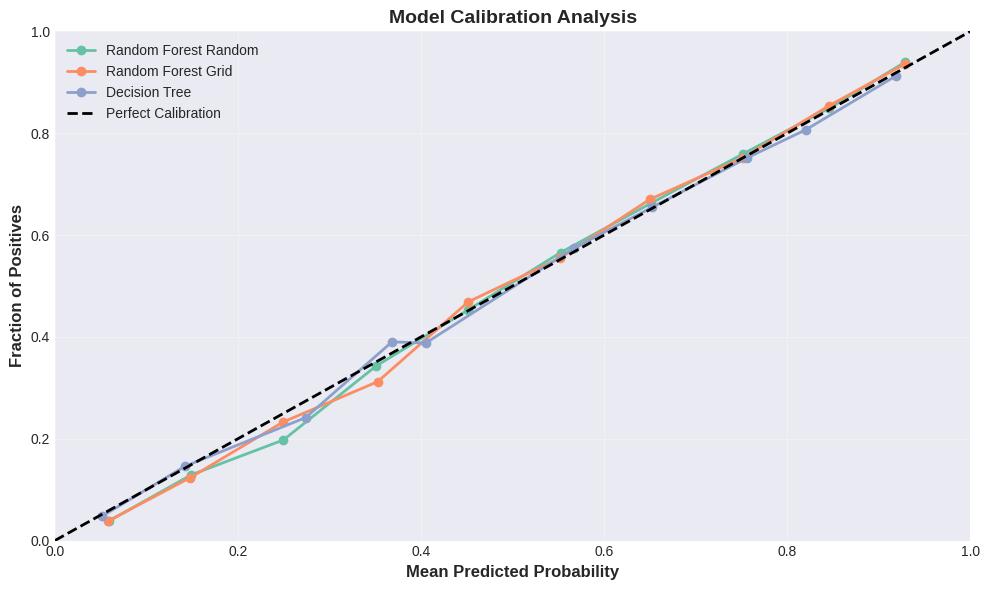

In [13]:
viz.plot_calibration_curve(
    models=models_dict,
    X_test=X_test,
    y_test=y_test,
    n_bins=10,
    title='Model Calibration Analysis'
)